# Making prelim plots for hue sensor results.

In [1]:
# Defining the condition names
blueNF = "blue_NF"
blueF  = "blue_Filter"
byNF   = "blue-yellow_NF"
byF    = "blue-yellow_Filter"
brNF   = "blue-red_NF"
brF    = "blue-red_Filter"
bfNF   = "blue-fixed_NF"
bfF    = "blue-fixed_Filter"
bsNF   = "blue-shifted_NF"
bsF    = "blue-shifted_Filter"

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

expFolder = "data1_04Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder

def loadfile(fileName):
    """
    fileName(condition): 'blue', 'blue-yellow', 'blue-red', 'blue-fixed', 'blue-shifted'
    returns a pandas DataFrame
    """
    f = base / f"{fileName}.txt"
    return pd.read_csv(f, sep="\t")

def plot1VarOvertime(fileName, var2plot):
    df          = loadfile(fileName)
    info2plot   = df[var2plot]
    titlex      = f"plot of {var2plot} over time cond = {fileName}"
    cx = {
    "B": "blue",
    "R": "red",
    "G": "green"
        }.get(var2plot, "black")
    plt.figure(figsize= (8,5))
    plt.plot(info2plot, color = cx)
    plt.ylabel(var2plot)
    plt.title(titlex)
    plt.grid(True)
    plt.show()

def plot2condsOverTime(f1, f2, var2plot):
    df1 = loadfile(f1)
    df2 = loadfile(f2)
    var1 = df1[var2plot]
    var2 = df2[var2plot]
    titlex  = f"comp of {var2plot}. {f1} vs. {f2}"
    plt.figure(figsize= (8,5))
    plt.plot(var1, color = "black", label=f1)
    plt.plot(var2, color = "orange", label=f2)
    plt.ylabel(var2plot)
    plt.title(titlex)
    plt.grid(True)
    plt.legend()
    plt.show()

    
def comp2condsRawOvertime(f1,f2):
    df1 = loadfile(f1)
    df2 = loadfile(f2)
    ymax1 = max(df1["R"].max(), df1["G"].max(), df1["B"].max())
    ymax2 = max(df2["R"].max(), df2["G"].max(), df2["B"].max())
    ymin, ymax = 0, max(ymax1,ymax2)   
    cols =2
    rows =1
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = axes.flatten()
    plot_idx = 0

    # Make plot for condition 1.
    ax = axes[plot_idx]
    ax.plot(df1["B"], color = "blue", label="B")
    ax.plot(df1["R"], color = "red", label="R")
    ax.plot(df1["G"], color = "green", label="G")
    ax.set_title(f1)
    ax.set_ylim(ymin, ymax)
    ax.legend()
    plot_idx += 1
    
    ax = axes[plot_idx]
    ax.plot(df2["B"], color = "blue", label="B")
    ax.plot(df2["R"], color = "red", label="R")
    ax.plot(df2["G"], color = "green", label="G")
    ax.set_title(f2)
    ax.set_ylim(ymin, ymax)
    
    plt.tight_layout()
    plt.show()

    
dfblue = loadfile(blueNF)
print(dfblue.head())

   Stim    R    G    B     C  Temp  HueLux  Yellow  Red  Blue  Blue2  Trig
0     1  415  508  418  1372  5228   361.0       0    0     0      0     1
1     1  415  509  419  1374  5237   361.0       0    0     0      0     1
2     1  414  507  417  1369  5228   360.0       0    0     0      0     1
3     1  416  506  417  1375  5210   358.0       0    0     0      0     1
4     1  416  509  419  1376  5228   361.0       0    0     0      0     1


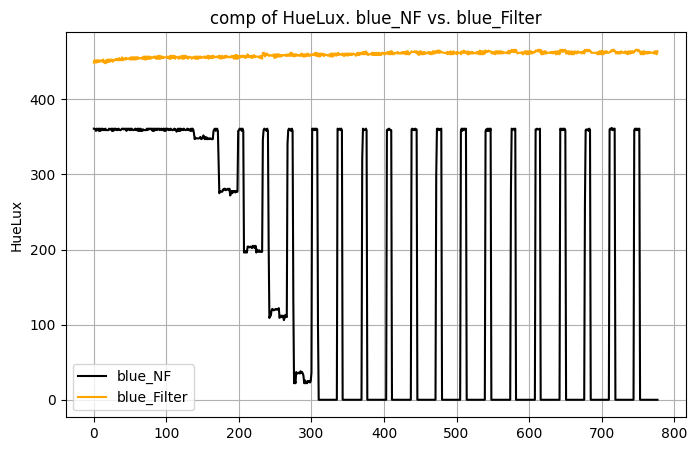

In [3]:
plot2condsOverTime(blueNF, blueF, "HueLux")

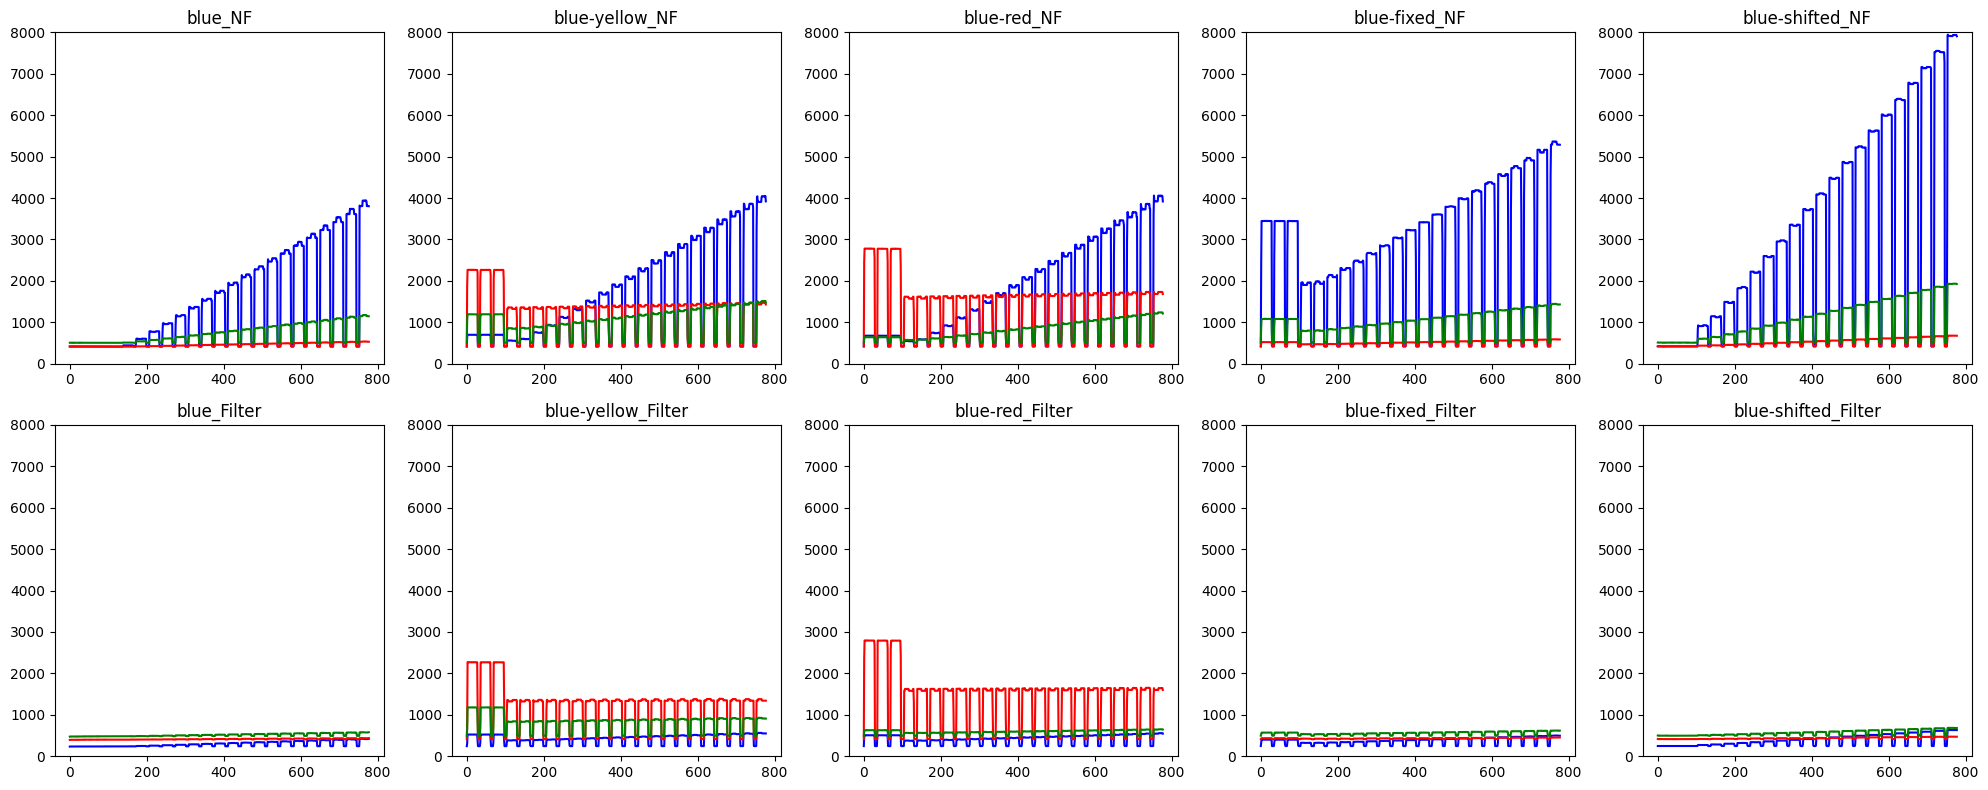

In [4]:
condNF = [blueNF, byNF,brNF,bfNF,bsNF]
condF  = [blueF, byF,brF,bfF,bsF]

ymin, ymax = 0, 8000   

cols = len(condF)
rows =2
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

plot_idx = 0

for condi in condNF:
    ax = axes[plot_idx]
    dfcx = loadfile(condi)   
    ax.plot(dfcx["B"], color = "blue")
    ax.plot(dfcx["R"], color = "red")
    ax.plot(dfcx["G"], color = "green")
    ax.set_title(condi)
    ax.set_ylim(ymin, ymax)
    plot_idx += 1

for condi in condF:
    ax = axes[plot_idx]
    dfcx = loadfile(condi)   
    ax.plot(dfcx["B"], color = "blue")
    ax.plot(dfcx["R"], color = "red")
    ax.plot(dfcx["G"], color = "green")
    ax.set_title(condi)
    ax.set_ylim(ymin, ymax)
    plot_idx += 1

plt.tight_layout()
plt.show()

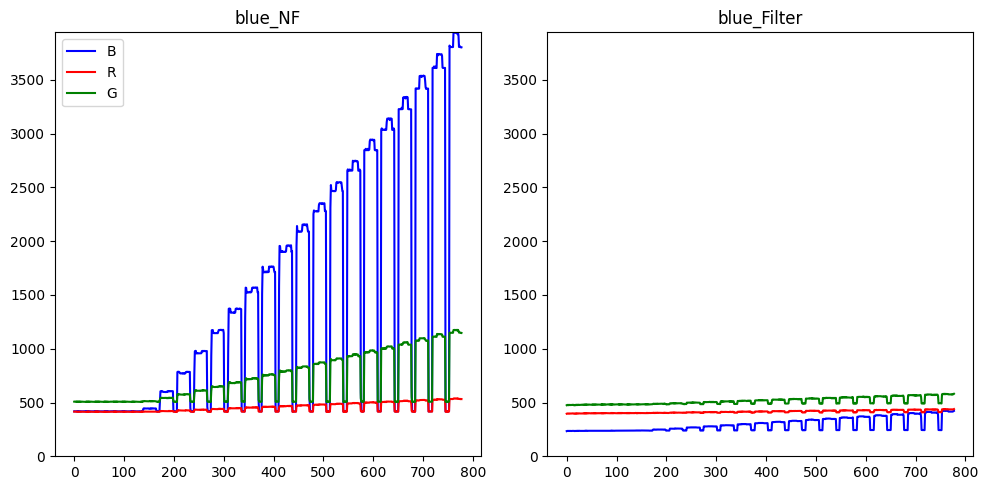

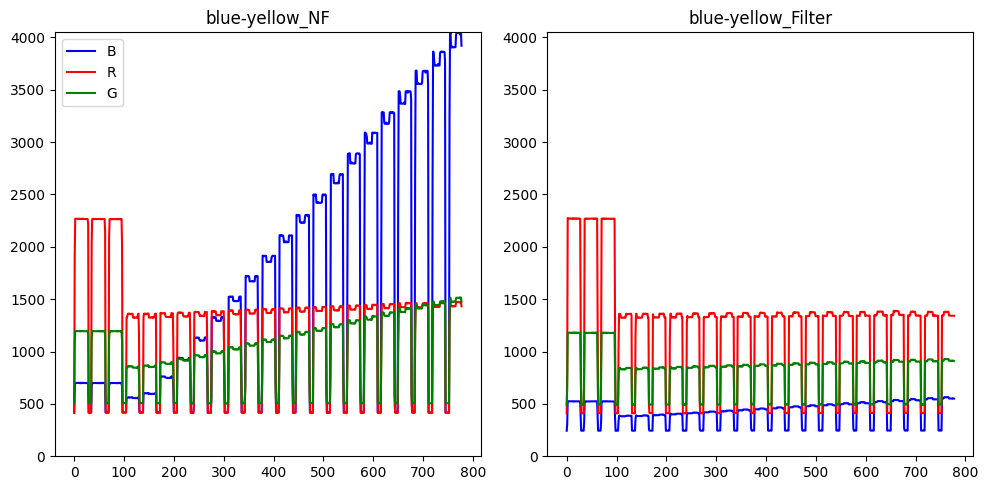

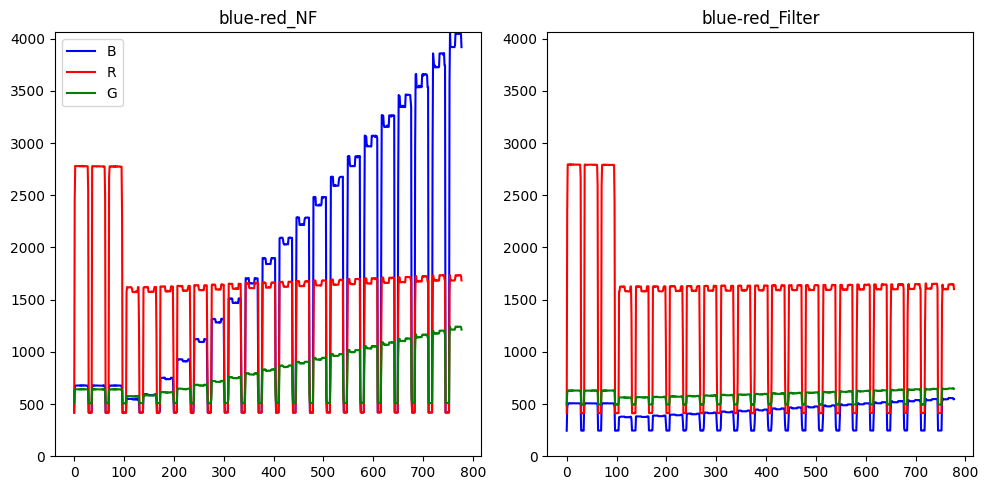

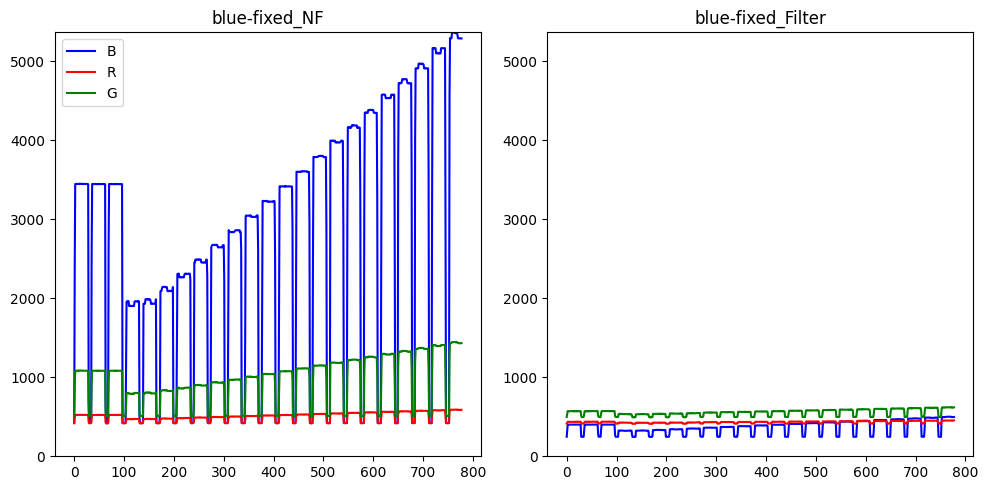

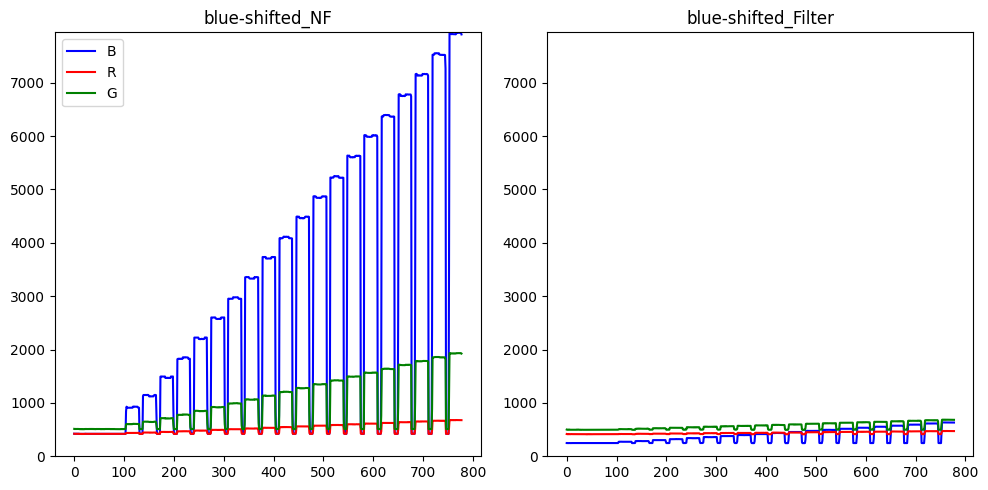

In [5]:
comp2condsRawOvertime(blueNF,blueF)
comp2condsRawOvertime(byNF,byF)
comp2condsRawOvertime(brNF,brF)
comp2condsRawOvertime(bfNF,bfF)
comp2condsRawOvertime(bsNF,bsF)